# Emoji based Sentiment Analysis


In [1]:
import pandas as pd
import numpy as np

# Preprocess Data

### Emoji Dataset Preprocessing

In [2]:
# prompt: mount google drice

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Setup the data for emoji
df_emoji = pd.read_csv("/content/drive/MyDrive/Sentiment Analysis/dataset/Emoji_Sentiment_Data.csv",
                       usecols = ['Emoji', 'Negative', 'Neutral', 'Positive'])
df_emoji

,Emoji,Negative,Neutral,Positive
0,😂,3614,4163,6845
1,❤,355,1334,6361
2,♥,252,1942,4950
3,😍,329,1390,4640
4,😭,2412,1218,1896
...,...,...,...,...
964,➛,0,1,0
965,♝,0,1,0
966,❋,0,1,0
967,✆,0,1,0


In [4]:
df_emoji.Emoji.values

array(['😂', '❤', '♥', '😍', '😭', '😘', '😊', '👌', '💕', '👏', '😁', '☺', '♡',
       '👍', '😩', '🙏', '✌', '😏', '😉', '🙌', '🙈', '💪', '😄', '😒', '💃', '💖',
       '😃', '😔', '😱', '🎉', '😜', '☯', '🌸', '💜', '💙', '✨', '😳', '💗', '★',
       '█', '☀', '😡', '😎', '😢', '💋', '😋', '🙊', '😴', '🎶', '💞', '😌', '🔥',
       '💯', '🔫', '💛', '💁', '💚', '♫', '😞', '😆', '😝', '😪', '�', '😫', '😅',
       '👊', '💀', '😀', '😚', '😻', '©', '👀', '💘', '🐓', '☕', '👋', '✋', '🎊',
       '🍕', '❄', '😥', '😕', '💥', '💔', '😤', '😈', '►', '✈', '🔝', '😰', '⚽',
       '😑', '👑', '😹', '👉', '🍃', '🎁', '😠', '🐧', '☆', '🍀', '🎈', '🎅', '😓',
       '😣', '😐', '✊', '😨', '😖', '💤', '💓', '👎', '💦', '✔', '😷', '⚡', '🙋',
       '🎄', '💩', '🎵', '➡', '😛', '😬', '👯', '💎', '🌿', '🎂', '🌟', '🔮', '❗',
       '👫', '🏆', '✖', '☝', '😙', '⛄', '👅', '♪', '🍂', '💏', '🔪', '🌴', '👈',
       '🌹', '🙆', '➜', '👻', '💰', '🍻', '🙅', '🌞', '🍁', '⭐', '▪', '🎀', '━',
       '☷', '🐷', '🙉', '🌺', '💅', '🐶', '🌚', '👽', '🎤', '👭', '🎧', '👆', '🍸',
       '🍷', '®', '🍉', '😇', '☑', '🏃', '😿', '│', '💣', '🍺', '▶', '😲

### Set to Binary Polarity and Normalize to 0 and 1

In [5]:
# compare the polarity of the dataset and turn the polarity to binary
# 0 = negative, 1= positive
polarity_ls = []
for index, row in df_emoji.iterrows():

    # polarity == sentiment
    # initial polarity is negative
    polarity = 0

    # positive if positive value is greater than negative value
    arg_1 = row['Positive'] > row['Negative']

    # positive if neutral value is odd and positive and negative value are equal
    arg_2 = row['Positive'] == row['Negative'] and row['Neutral'] % 2 != 0

    # positive if either of the two arguments are true
    if arg_1 or arg_2:
        polarity = 1
    polarity_ls.append(polarity)

# create new emoji dataset
new_df_emoji = pd.DataFrame(polarity_ls, columns=['sentiment'])
new_df_emoji['emoji'] = df_emoji['Emoji'].values
new_df_emoji

,sentiment,emoji
0,1,😂
1,1,❤
2,1,♥
3,1,😍
4,0,😭
...,...,...
964,1,➛
965,1,♝
966,1,❋
967,1,✆


### Tweet Posts Dataset Prerprocessing

A <b>10k size dataset is provided</b> in the folder but you can download a 1.6m data online.

To download the 1.6m tweet dataset (optional)
https://www.kaggle.com/kazanova/sentiment140


In [6]:
df_posts = pd.read_csv("/content/drive/MyDrive/Sentiment Analysis/dataset/processed_tweet_dataset.csv")
df_posts = df_posts.drop([df_posts.columns[0]], axis=1)
df_posts

,sentiment,post
0,0,"- Awww, that's a bummer. You shoulda got David..."
1,0,Picked Mich St to win it all from the get go. ...
2,0,throat is closing up and i had some string che...
3,0,"If he doesn't get better in a few days, he cou..."
4,0,I'm sure everyone has ruined my gift to you Wh...
...,...,...
9995,1,- i know now what is that haha X)
9996,1,- had a great time with some of the best peopl...
9997,1,"Tyreseee, when you're heading to The Netherlan..."
9998,1,"don't know what you could possibly mean, dear ..."


# Classification using Naive Bayes

Naive Bayes is a simple technique for constructing classifiers: models that assign class labels to problem instances, represented as vectors of feature values, where the class labels are drawn from some finite set.

In [7]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn import naive_bayes
from sklearn.metrics import roc_auc_score

### tf–idf or TFIDF

short for <b>term frequency–inverse document frequency</b>, is a numerical statistic that is intended to reflect <b>how important a word is</b> to a document in a collection or corpus.

In [8]:
!pip install nltk
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
# TFIDF vectorizer
stopset = set(stopwords.words('english'))
vectorizer = TfidfVectorizer(use_idf=True, lowercase=True,
                            strip_accents='ascii', stop_words=stopset)

In [10]:
# print out the emoticons and sentiment values
e_c, p = 0, 0
for index, row in new_df_emoji.iterrows():
    print(f"{row['emoji']} = {row['sentiment']}")
    p += 1 if row['sentiment'] else 0
    e_c += 1

😂 = 1
❤ = 1
♥ = 1
😍 = 1
😭 = 0
😘 = 1
😊 = 1
👌 = 1
💕 = 1
👏 = 1
😁 = 1
☺ = 1
♡ = 1
👍 = 1
😩 = 0
🙏 = 1
✌ = 1
😏 = 1
😉 = 1
🙌 = 1
🙈 = 1
💪 = 1
😄 = 1
😒 = 0
💃 = 1
💖 = 1
😃 = 1
😔 = 0
😱 = 1
🎉 = 1
😜 = 1
☯ = 1
🌸 = 1
💜 = 1
💙 = 1
✨ = 1
😳 = 1
💗 = 1
★ = 1
█ = 0
☀ = 1
😡 = 0
😎 = 1
😢 = 1
💋 = 1
😋 = 1
🙊 = 1
😴 = 0
🎶 = 1
💞 = 1
😌 = 1
🔥 = 1
💯 = 1
🔫 = 0
💛 = 1
💁 = 1
💚 = 1
♫ = 1
😞 = 0
😆 = 1
😝 = 1
😪 = 0
� = 1
😫 = 0
😅 = 1
👊 = 1
💀 = 0
😀 = 1
😚 = 1
😻 = 1
© = 1
👀 = 1
💘 = 1
🐓 = 1
☕ = 1
👋 = 1
✋ = 1
🎊 = 1
🍕 = 1
❄ = 1
😥 = 1
😕 = 0
💥 = 1
💔 = 0
😤 = 0
😈 = 1
► = 1
✈ = 1
🔝 = 1
😰 = 0
⚽ = 1
😑 = 0
👑 = 1
😹 = 1
👉 = 1
🍃 = 1
🎁 = 1
😠 = 0
🐧 = 1
☆ = 1
🍀 = 1
🎈 = 1
🎅 = 1
😓 = 0
😣 = 0
😐 = 0
✊ = 1
😨 = 0
😖 = 0
💤 = 1
💓 = 1
👎 = 0
💦 = 1
✔ = 1
😷 = 0
⚡ = 1
🙋 = 1
🎄 = 1
💩 = 0
🎵 = 1
➡ = 1
😛 = 1
😬 = 1
👯 = 1
💎 = 1
🌿 = 1
🎂 = 1
🌟 = 1
🔮 = 1
❗ = 1
👫 = 1
🏆 = 1
✖ = 1
☝ = 1
😙 = 1
⛄ = 1
👅 = 1
♪ = 1
🍂 = 1
💏 = 1
🔪 = 1
🌴 = 1
👈 = 1
🌹 = 1
🙆 = 1
➜ = 1
👻 = 1
💰 = 1
🍻 = 1
🙅 = 0
🌞 = 1
🍁 = 1
⭐ = 1
▪ = 1
🎀 = 1
━ = 1
☷ = 1
🐷 = 1
🙉 = 1
🌺 = 1
💅 = 1
🐶 = 1
🌚 = 1
👽 = 1
🎤 = 1
👭 = 1
🎧 = 

In [11]:
print(f'Total Positive Emojis are ({p}:{e_c}) or {round(p / e_c * 100)}%')

Total Positive Emojis are (795:969) or 82%


In [12]:
new_df_post = df_posts

In [13]:
# dependent variable will be linked as:
# 0 = negative, 1 = positive
y = new_df_post.sentiment
vectorizer = TfidfVectorizer(stop_words='english')
# convert 'sentence' from text to features
X = vectorizer.fit_transform(new_df_post.post)

print(y.shape)
print(X.shape)
print(f'{X.shape[0]} observations X {X.shape[1]} unique words')


(10000,)
(10000, 13230)
10000 observations X 13230 unique words


### Training


In [14]:
# # Test Train Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=None)

# # we will train a naive bayes classifier
# # clf = naive_bayes.MultinomialNB()
# clf = naive_bayes.BernoulliNB()

# clf.fit(X_train, y_train)

# # test our models accuracy
# roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])

In [15]:
# Test Train Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=None)

# we will train a naive bayes classifier
clf = naive_bayes.MultinomialNB()
# clf = naive_bayes.BernoulliNB()

clf.fit(X_train, y_train)

# test our models accuracy
roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])


0.7902685293989642

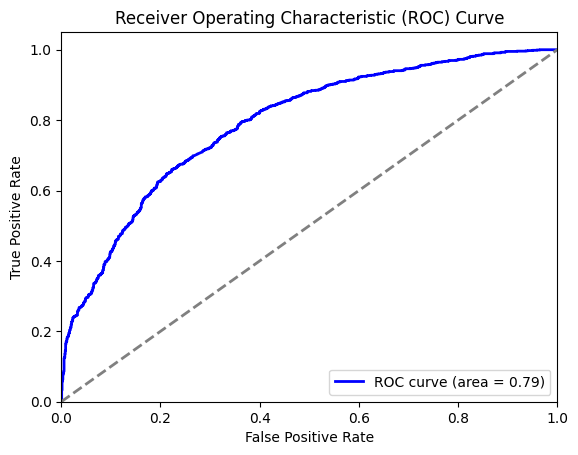

In [16]:
# Import necessary libraries
import matplotlib.pyplot as plt
from sklearn import metrics

# Assuming you have already defined and trained your model:
# clf.fit(X_train, y_train)

# Predict probabilities for the test set
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [19]:
# print('Unique values in y_test:', set(y_test))
# print('Unique values in y_pred:', set(y_pred))


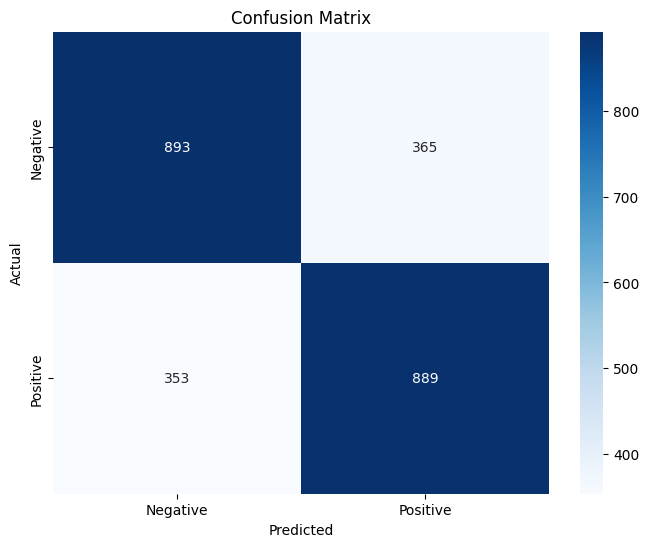

Accuracy: 0.71
Precision: 0.71
Recall: 0.72
F1 Score: 0.71
Classification Report:
               precision    recall  f1-score   support

    Negative       0.72      0.71      0.71      1258
    Positive       0.71      0.72      0.71      1242

    accuracy                           0.71      2500
   macro avg       0.71      0.71      0.71      2500
weighted avg       0.71      0.71      0.71      2500



In [20]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict labels for the test set
y_pred = clf.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Precision
precision = precision_score(y_test, y_pred, pos_label=1)
print(f'Precision: {precision:.2f}')

# Recall
recall = recall_score(y_test, y_pred, pos_label=1)
print(f'Recall: {recall:.2f}')

# F1 Score
f1 = f1_score(y_test, y_pred, pos_label=1)
print(f'F1 Score: {f1:.2f}')

# Classification Report
class_report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])
print('Classification Report:\n', class_report)



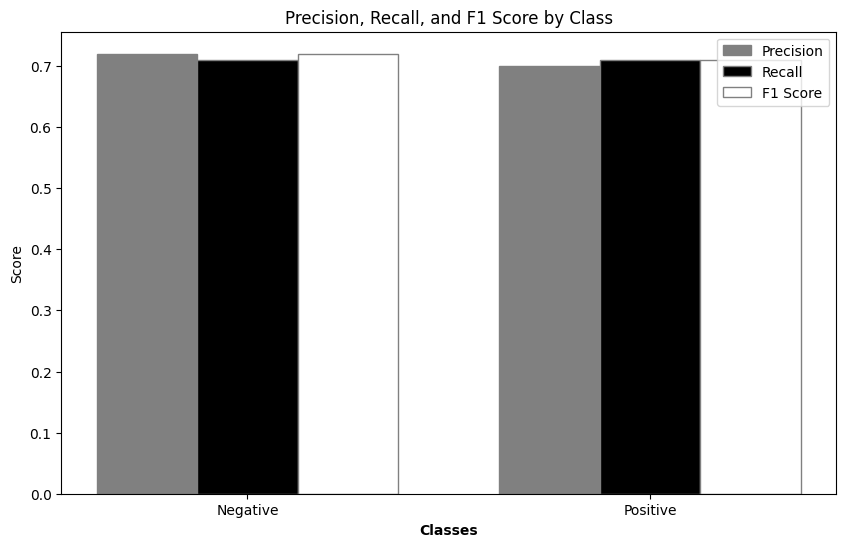

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for each class
classes = ['Negative', 'Positive']
precision_scores = [0.72, 0.70]
recall_scores = [0.71, 0.71]
f1_scores = [0.72, 0.71]

# Set width of bar
barWidth = 0.25

# Set position of bar on X axis
r1 = np.arange(len(precision_scores))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

# Make the plot
plt.figure(figsize=(10, 6))
plt.bar(r1, precision_scores, color='grey', width=barWidth, edgecolor='grey', label='Precision')
plt.bar(r2, recall_scores, color='black', width=barWidth, edgecolor='grey', label='Recall')
plt.bar(r3, f1_scores, color='white', width=barWidth, edgecolor='grey', label='F1 Score')

# Add xticks on the middle of the group bars
plt.xlabel('Classes', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(precision_scores))], classes)

# Add labels and title
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score by Class')
plt.legend()

# Show plot
plt.show()


### Processing the inputs - Extraction of emoji and texts

In [22]:
!pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.4/431.4 kB 3.1 MB/s eta 0:00:00


In [23]:
import emoji

text = "#samplesenti @emojitweets i ❤❤❤ sentiment &quot; analysis &quot; http://senti.com/pic_01.jpg "
def extract_text_and_emoji(text=text):
    global allchars, emoji_list

    # remove all tagging and links, not needed for sentiments
    remove_keys = ('@', 'http://', '&', '#')
    clean_text = ' '.join(txt for txt in text.split() if not txt.startswith(remove_keys))

    # setup the input, get the characters and the emoji lists
    allchars = [c for c in clean_text]
    emoji_list = [c for c in allchars if emoji.is_emoji(c)]

    # extract text
    clean_text = ' '.join([str for str in clean_text.split() if not any(i in str for i in emoji_list)])

    # extract emoji
    clean_emoji = ''.join([str for str in text.split() if any(i in str for i in emoji_list)])
    return (clean_text, clean_emoji)

### Get the sentiments of the processed posts

In [24]:
# def get_sentiment(s_input = 'i dislike this song'):
#     # turn input into array
#     input_array= np.array([s_input])
#     # vectorize the input
#     input_vector = vectorizer.transform(input_array)
#     # predict the score of vector
#     pred_senti = clf.predict(input_vector)

#     return pred_senti[0]
# print(get_sentiment())

In [25]:
def get_sentiment(s_input='i like this song'):
    # Turn input into array
    input_array = np.array([s_input])
    # Vectorize the input
    input_vector = vectorizer.transform(input_array)
    # Predict the probability scores of the vector for each class
    pred_proba = clf.predict_proba(input_vector)
    # Get the probability for the positive class (index 1)
    positive_prob = pred_proba[0, 1]
    # Return the sentiment label based on positive probability
    if positive_prob >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"
    # Return the sentiment label and polarity value
    return sentiment, positive_prob

sentiment, polarity = get_sentiment()
print("Sentiment:", sentiment)
print("Polarity Value:", polarity)


Sentiment: Positive
Polarity Value: 0.656255192693519


In [26]:
def get_emoji_sentiment(emoji_ls = '😡❤❤😡❤', emoji_df = new_df_emoji):
    emoji_val_ls = []
    for e in emoji_ls:
        get_emo_senti = [row['sentiment'] for index, row in emoji_df.iterrows() if row['emoji'] == e]
        emoji_val_ls.append(get_emo_senti[0])
    return emoji_val_ls

ges = get_emoji_sentiment()
print('Sentiment value of each emoji:',ges)

Sentiment value of each emoji: [0, 1, 1, 0, 1]


#extra


In [95]:
# def get_emoji_sentiment(emoji_ls, emoji_df):
#     emoji_val_ls = []
#     for e in emoji_ls:
#         get_emo_senti = [row['sentiment'] for index, row in emoji_df.iterrows() if row['emoji'] == e]
#         if get_emo_senti:
#             emoji_val_ls.append(get_emo_senti[0])
#         else:
#             emoji_val_ls.append(None)  # Handle the case when sentiment is not found for an emoji
#     return emoji_val_ls


def get_emoji_sentiment(emoji_ls, emoji_df):
    emoji_val_ls = []
    for e in emoji_ls:
        get_emo_senti = [row['sentiment'] for index, row in emoji_df.iterrows() if row['emoji'] == e]
        if get_emo_senti:
            emoji_val_ls.append(get_emo_senti[0])
        else:
            # Return a default sentiment value when emoji sentiment is not found
            emoji_val_ls.append(0)  # You can set any default sentiment value here
    return emoji_val_ls


### Building the sentiment analysis

In [96]:
def get_text_emoji_sentiment(input_test='i hate this love song 😡❤'):
    # Separate text and emoji
    (ext_text, ext_emoji) = extract_text_and_emoji(input_test)
    print(f'\tExtracted: "{ext_text}" , {ext_emoji}')

    # Get text sentiment
    senti_text = get_sentiment(ext_text)
    text_value = senti_text[1]  # Extract the numerical value from the tuple
    print(f'\tText value: {text_value}')

    # Get emoji sentiment
    senti_emoji_value = sum(get_emoji_sentiment(ext_emoji, new_df_emoji))
    print_emo_val_avg = 0 if len(ext_emoji) == 0 else senti_emoji_value / len(ext_emoji)
    print(f'\tEmoji average value: {print_emo_val_avg}')

    # Average the sentiment of emojis and text
    senti_avg = (senti_emoji_value + text_value) / (len(ext_emoji) + 1)
    print(f'\tAverage value: {senti_avg}')

    # Set value of avg sentiment to either pos or neg
    senti_truth = "Positive Sentiment" if senti_avg >= 0.5 else "Negative Sentiment"

    return senti_truth

print(get_text_emoji_sentiment())


	Extracted: "i hate this love song" , 😡❤
	Text value: 0.4503455241195121
	Emoji average value: 0.5
	Average value: 0.4834485080398374
Negative Sentiment


In [41]:
import re

def clean_comment(comment):
    # Remove commas
    comment = comment.replace(",", "")


    # Remove non-text characters
    comment = re.sub(r"[^a-zA-Z0-9\s]", "", comment)

    # Remove links
    comment = re.sub(r"http\S+|www\S+|https\S+", "", comment)

    return comment.strip()

def get_text_emoji_sentiment(input_test='i ❤❤❤ sentiment analysis'):
    # # Clean the comment
    # cleaned_comment = clean_comment(input_test)

    # Separate text and emoji
    (ext_text, ext_emoji) = extract_text_and_emoji(input_test)
    print(f'\tExtracted: "{ext_text}" , {ext_emoji}')

    # Get text sentiment
    senti_text = get_sentiment(ext_text)
    text_value = senti_text[1]  # Extract the numerical value from the tuple
    print(f'\tText value: {text_value}')

    # Get emoji sentiment
    senti_emoji_value = sum(get_emoji_sentiment(ext_emoji, new_df_emoji))
    print_emo_val_avg = 0 if len(ext_emoji) == 0 else senti_emoji_value / len(ext_emoji)
    print(f'\tEmoji average value: {print_emo_val_avg}')

    # Average the sentiment of emojis and text
    senti_avg = (senti_emoji_value + text_value) / (len(ext_emoji) + 1)
    print(f'\tAverage value: {senti_avg}')


    # set value of avg sentiment to either pos, neg, or neu
    if senti_avg >= 0.5:
        senti_truth = "Positive"
    elif senti_avg < 0.5:
        senti_truth = "Negative"
    else:
        senti_truth = "Neutral"

    return senti_truth

# # Example usage                            This is the same as above code
# sentiment = get_text_emoji_sentiment()
# print(f"Sentiment: {sentiment}")

# Calculate percentages
num_positive = 0
num_negative = 0
num_neutral = 0
num_total = 0

# Iterate over a list of comments and calculate sentiment percentages
comments = ["I love it❤!", "It's terrible.", "Not sure.", "Great job!❤❤", "i hate everything.", "Check out this link: https://example.com"]
for comment in comments:
    cleaned_comment = clean_comment(comment)
    if not cleaned_comment:
        continue

    sentiment = get_text_emoji_sentiment(cleaned_comment)
    if sentiment == "Positive":
        print("Sentiment is positive\n")
        num_positive += 1
    elif sentiment == "Negative":
        print("Sentiment is negative\n")
        num_negative += 1
    else:
        print("Sentiment is negative\n")
        num_neutral += 1
    num_total += 1

percentage_positive = (num_positive / num_total) * 100
percentage_negative = (num_negative / num_total) * 100
percentage_neutral = (num_neutral / num_total) * 100

print(f"Percentage of positive comments: {percentage_positive}%")
print(f"Percentage of negative comments: {percentage_negative}%")
print(f"Percentage of neutral comments: {percentage_neutral}%")

	Extracted: "I love it" , 
	Text value: 0.7104260965931654
	Emoji average value: 0
	Average value: 0.7104260965931654
Sentiment is positive

	Extracted: "Its terrible" , 
	Text value: 0.21565392899927527
	Emoji average value: 0
	Average value: 0.21565392899927527
Sentiment is negative

	Extracted: "Not sure" , 
	Text value: 0.6204295007937268
	Emoji average value: 0
	Average value: 0.6204295007937268
Sentiment is positive

	Extracted: "Great job" , 
	Text value: 0.6104820169983217
	Emoji average value: 0
	Average value: 0.6104820169983217
Sentiment is positive

	Extracted: "i hate everything" , 
	Text value: 0.12457767784090011
	Emoji average value: 0
	Average value: 0.12457767784090011
Sentiment is negative

	Extracted: "Check out this link" , 
	Text value: 0.7465476581572957
	Emoji average value: 0
	Average value: 0.7465476581572957
Sentiment is positive

Percentage of positive comments: 66.66666666666666%
Percentage of negative comments: 33.33333333333333%
Percentage of neutral comm

### Print the tweets with emoji

In [46]:
def get_text_emoji_sentiment(input_test = 'i ❤ ❤ ❤ 😡 sentiment analysis'):
    # Separate text and emoji
    (ext_text, ext_emoji) = extract_text_and_emoji(input_test)
    print(f'\tExtracted: "{ext_text}" , {ext_emoji}')

    # Get text sentiment
    senti_text = get_sentiment(ext_text)
    text_value = senti_text[1]  # Extract the numerical value from the tuple
    print(f'\tText value: {text_value}')

    # Get emoji sentiment
    senti_emoji_value = sum(get_emoji_sentiment(ext_emoji, new_df_emoji))
    print_emo_val_avg = 0 if len(ext_emoji) == 0 else senti_emoji_value / len(ext_emoji)
    print(f'\tEmoji average value: {print_emo_val_avg}')

    # Average the sentiment of emojis and text
    senti_avg = (senti_emoji_value + text_value) / (len(ext_emoji) + 1)
    print(f'\tAverage value: {senti_avg}')


    # set value of avg sentiment to either pos or neg
    # senti_truth = "Positive" if senti_avg > 0.5 else "Negative"
    if senti_avg >0.5:
      senti_truth = "Positive"
    elif senti_avg == 0.5:
      senti_truth = "Neutral"
    else:
      senti_truth = "Negative"

    return senti_truth

# print(get_text_emoji_sentiment())

def print_senti_status(test):
    print('========================================')
    print(f'Your input is "{test}" \n')
    sentiment = get_text_emoji_sentiment(test)
    print(f'\nYour input is of "{sentiment}" sentiment'.upper())
    print('========================================')

def calculate_sentiment_percentages(comments):
    num_positive = 0
    num_negative = 0
    num_neutral = 0
    num_total = 0

    for comment in comments:
        cleaned_comment = clean_comment(comment)
        if not cleaned_comment:
            continue

        sentiment = get_text_emoji_sentiment(cleaned_comment)
        if sentiment == "Positive":
            num_positive += 1
        elif sentiment == "Negative":
            num_negative += 1
        else:
            num_neutral += 1
        num_total += 1

    percentage_positive = (num_positive / num_total) * 100
    percentage_negative = (num_negative / num_total) * 100
    percentage_neutral = (num_neutral / num_total) * 100

    return percentage_positive, percentage_negative, percentage_neutral

# Take user input
user_input = input("Enter your comment: ")

# Check sentiment of user input
print_senti_status(user_input)

# Calculate sentiment percentages for user input
percentage_positive, percentage_negative, percentage_neutral = calculate_sentiment_percentages([user_input])

print(f"\nPercentage of positive comments: {percentage_positive}%")
print(f"Percentage of negative comments: {percentage_negative}%")
print(f"Percentage of neutral comments: {percentage_neutral}%")

Enter your comment: i hate this love song 😡❤
Your input is "i hate this love song 😡❤" 

	Extracted: "i hate this love song" , 😡❤
	Text value: 0.4503455241195121
	Emoji average value: 0.5
	Average value: 0.4834485080398374

YOUR INPUT IS OF "NEGATIVE" SENTIMENT
	Extracted: "i hate this love song" , 
	Text value: 0.4503455241195121
	Emoji average value: 0
	Average value: 0.4503455241195121

Percentage of positive comments: 0.0%
Percentage of negative comments: 100.0%
Percentage of neutral comments: 0.0%


## Tweet Something

In [47]:
import ipywidgets as widgets
import warnings; warnings.simplefilter('ignore')

In [48]:
# for text area
l = widgets.Layout(flex='0 1 auto', height='50px',width='auto')
post_tweet = widgets.Textarea(value='🎶 Tweet 🐤 your feelings 😲 🎶', layout=l)
print(post_tweet.value)
# for button
button = widgets.Button(description="Say your Sentiments!")
output = widgets.Output()

def on_tweet_clicked(b):
    output.clear_output()
    with output:
        output.layout={'border': '1px solid black'}
        print_senti_status(post_tweet.value)


🎶 Tweet 🐤 your feelings 😲 🎶


In [49]:
display(post_tweet,button, output)
button.on_click(on_tweet_clicked)

Textarea(value='🎶 Tweet 🐤 your feelings 😲 🎶', layout=Layout(flex='0 1 auto', height='50px', width='auto'))

Button(description='Say your Sentiments!', style=ButtonStyle())

Output()

### Conclusion
This is method 1. Where the training of the tweets are sepparate from the emoticons. the emoticons are assigned with their own sentiment polarity. then to analyze the sentiment of the tweet, we combine and average the sentiment value of both the emoticons and texts. this method will have a strong influence emoticon with a non-changing polarity value.

In [50]:
emoticon_mapping = {
    ":)": 1,  # positive
    ":(": -1,  # negative
    ":|": 0,  # neutral
    # Add more emoticons and their sentiment scores as needed
}

In [51]:
def calculate_emoticon_sentiment(text):
    emoticon_sentiment = 0
    for emoticon, sentiment in emoticon_mapping.items():
        if emoticon in text:
            emoticon_sentiment += sentiment
    return emoticon_sentiment

In [52]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

def analyze_sentiment(text):
    sia = SentimentIntensityAnalyzer()
    sentiment_score = sia.polarity_scores(text)
    return sentiment_score['pos'], sentiment_score['neg']


In [53]:
def get_overall_sentiment(emoticon_sentiment, sentiment_score):
    overall_sentiment = emoticon_sentiment + sentiment_score
    return overall_sentiment

In [54]:
def calculate_percentage(overall_sentiment):
    positive_percentage = max(0, overall_sentiment) * 100
    negative_percentage = abs(min(0, overall_sentiment)) * 100
    return positive_percentage, negative_percentage

In [64]:
from textblob import TextBlob

# Prompt the user for a comment
text = input("Enter your comment: ")

# Perform sentiment analysis
blob = TextBlob(text)
sentiment = blob.sentiment.polarity

# Calculate the percentage of positive and negative sentiment
positive_percentage = (sentiment + 1) * 50
negative_percentage = (1 - sentiment) * 50

# Print results
print("Positive percentage: {:.1f}%".format(positive_percentage))
print("Negative percentage: {:.1f}%".format(negative_percentage))

Enter your comment: i hate love songs
Positive percentage: 42.5%
Negative percentage: 57.5%


In [56]:
!pip install vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.2 MB/s eta 0:00:00


In [65]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Prompt the user for a comment
text = input("Enter your comment: ")

# Perform sentiment analysis using VADER
analyzer = SentimentIntensityAnalyzer()
sentiment_scores = analyzer.polarity_scores(text)

# Get the positive, negative, and neutral scores
positive_score = sentiment_scores['pos']
negative_score = sentiment_scores['neg']
neutral_score = sentiment_scores['neu']

# Calculate the percentage of positive, negative, and neutral sentiment
total_score = positive_score + negative_score + neutral_score
positive_percentage = (positive_score / total_score) * 100
negative_percentage = (negative_score / total_score) * 100
neutral_percentage = (neutral_score / total_score) * 100

# Print results
print("Positive percentage: {:.1f}%".format(positive_percentage))
print("Negative percentage: {:.1f}%".format(negative_percentage))
print("Neutral percentage: {:.1f}%".format(neutral_percentage))

Enter your comment: i hate love songs
Positive percentage: 42.4%
Negative percentage: 37.4%
Neutral percentage: 20.2%


In [58]:
# @title
!pip install vaderSentiment

In [ ]:
# @title
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Prompt the user for a comment
text = input("Enter your comment: ")

# Perform sentiment analysis using VADER
sid = SentimentIntensityAnalyzer()
sentiment_scores = sid.polarity_scores(text)

# Get the sentiment label and score
sentiment_label = "Positive" if sentiment_scores["compound"] >= 0 else "Negative"
sentiment_score = abs(sentiment_scores["compound"])

# Calculate the percentage of positive and negative sentiment
positive_percentage = sentiment_score * 100
negative_percentage = (1 - sentiment_score) * 100

# Print results
print("Sentiment: ", sentiment_label)
print("Positive percentage: {:.1f}%".format(positive_percentage))
print("Negative percentage: {:.1f}%".format(negative_percentage))

In [60]:
!pip install flair

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.3/388.3 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 2.6 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none

In [66]:
from flair.models import TextClassifier
from flair.data import Sentence

# Prompt the user for a comment
text = input("Enter your comment: ")

# Load the sentiment analysis model
model = TextClassifier.load("en-sentiment")

# Create a Sentence object
sentence = Sentence(text)

# Predict the sentiment
model.predict(sentence)

# Get the sentiment label and score
sentiment_label = sentence.labels[0].value
sentiment_score = sentence.labels[0].score

# Calculate the percentage of positive and negative sentiment
if sentiment_label == "POSITIVE":
  positive_percentage = sentiment_score * 100
  negative_percentage = (1 - sentiment_score) * 100
else:
  negative_percentage = sentiment_score * 100
  positive_percentage = (1 - sentiment_score) * 100


# Print results
print("Sentiment: ", sentiment_label)
print("Positive percentage: {:.1f}%".format(positive_percentage))
print("Negative percentage: {:.1f}%".format(negative_percentage))

Enter your comment: i love songs
Sentiment:  POSITIVE
Positive percentage: 98.1%
Negative percentage: 1.9%


In [62]:
from transformers import AutoModelForSequenceClassification
from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoConfig
import numpy as np
from scipy.special import softmax
# Preprocess text (username and link placeholders)
def preprocess(text):
    new_text = []
    for t in text.split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
# PT
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
#model.save_pretrained(MODEL)

# Prompt the user for a comment
text = input("Enter your comment: ")

text = preprocess(text)
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
# # TF
# model = TFAutoModelForSequenceClassification.from_pretrained(MODEL)
# model.save_pretrained(MODEL)
# text = "Covid cases are increasing fast!"
# encoded_input = tokenizer(text, return_tensors='tf')
# output = model(encoded_input)
# scores = output[0][0].numpy()
# scores = softmax(scores)
# Print labels and scores
ranking = np.argsort(scores)
ranking = ranking[::-1]
for i in range(scores.shape[0]):
    l = config.id2label[ranking[i]]
    s = scores[ranking[i]]
    print(f"{i+1}) {l} {np.round(float(s), 4)}")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Enter your comment: i hate love songs
1) negative 0.8806
2) neutral 0.1013
3) positive 0.018


In [101]:
# Import necessary libraries
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from flair.models import TextClassifier
from flair.data import Sentence
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig
import numpy as np
from scipy.special import softmax
import pandas as pd

def get_text_emoji_sentiment_naive_bayes(input_test='i hate this love song 😡❤'):
    ext_text, ext_emoji = extract_text_and_emoji(input_test)
    senti_text = get_sentiment(ext_text)
    text_value = senti_text[1]  # Extract the numerical value from the tuple
    # print("Polarity Score:", text_value)  # Print polarity score for debugging
    senti_emoji_value = sum(get_emoji_sentiment(ext_emoji, new_df_emoji))
    senti_avg = (senti_emoji_value + text_value) / (len(ext_emoji) + 1)
    senti_truth = "Positive" if senti_avg >= 0.5 else "Negative"

    positive_score = text_value * 100
    negative_score = 100 - positive_score

    return senti_truth, positive_score, negative_score  # Returning sentiment scores without polarity

# Define a function for TextBlob Model
def get_sentiment_textblob(text):
    blob = TextBlob(text)
    sentiment = blob.sentiment.polarity
    positive_percentage = (sentiment + 1) * 50
    negative_percentage = (1 - sentiment) * 50
    return "Positive" if sentiment >= 0 else "Negative", positive_percentage, negative_percentage

# Define a function for VADER Model
def get_sentiment_vader(text):
    analyzer = SentimentIntensityAnalyzer()
    sentiment_scores = analyzer.polarity_scores(text)
    positive_score = sentiment_scores['pos']
    negative_score = sentiment_scores['neg']
    neutral_score = sentiment_scores['neu']
    total_score = positive_score + negative_score + neutral_score
    positive_percentage = (positive_score / total_score) * 100
    negative_percentage = (negative_score / total_score) * 100
    neutral_percentage = (neutral_score / total_score) * 100
    return "Positive" if positive_score >= negative_score else "Negative", positive_percentage, negative_percentage, neutral_percentage

# Define a function for Flair Model
def get_sentiment_flair(text):
    model = TextClassifier.load("en-sentiment")
    sentence = Sentence(text)
    model.predict(sentence)
    sentiment_label = sentence.labels[0].value
    sentiment_score = sentence.labels[0].score
    if sentiment_label == "POSITIVE":
        positive_percentage = sentiment_score * 100
        negative_percentage = (1 - sentiment_score) * 100
    else:
        negative_percentage = sentiment_score * 100
        positive_percentage = (1 - sentiment_score) * 100
    return sentiment_label, positive_percentage, negative_percentage

# Define a function for RoBERTa Model
def get_sentiment_roberta(text):
    MODEL = f"cardiffnlp/twitter-roberta-base-sentiment-latest"
    tokenizer = AutoTokenizer.from_pretrained(MODEL)
    config = AutoConfig.from_pretrained(MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL)
    text = preprocess(text)
    encoded_input = tokenizer(text, return_tensors='pt')
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    ranking = np.argsort(scores)[::-1]
    results = {config.id2label[ranking[i]]: float(scores[ranking[i]]) for i in range(scores.shape[0])}
    return results
# Master function to get sentiment from all models and create a comparison table
def compare_models(input_text):
    results = []

    # Naive Bayes Model
    naive_bayes_sentiment, polarity_score, negative_score = get_text_emoji_sentiment_naive_bayes(input_text)
    results.append(['Naive Bayes', naive_bayes_sentiment, polarity_score, polarity_score, 100 - polarity_score, 'N/A'])

    # TextBlob Model
    textblob_sentiment, textblob_positive, textblob_negative = get_sentiment_textblob(input_text)
    results.append(['TextBlob', textblob_sentiment, 'N/A', textblob_positive, textblob_negative, 'N/A'])

    # VADER Model
    vader_sentiment, vader_positive, vader_negative, vader_neutral = get_sentiment_vader(input_text)
    results.append(['VADER', vader_sentiment, 'N/A', vader_positive, vader_negative, vader_neutral])

    # Flair Model
    flair_sentiment, flair_positive, flair_negative = get_sentiment_flair(input_text)
    results.append(['Flair', flair_sentiment, 'N/A', flair_positive, flair_negative, 'N/A'])

    # RoBERTa Model
    roberta_results = get_sentiment_roberta(input_text)
    roberta_sentiment = max(roberta_results, key=roberta_results.get)
    roberta_positive = roberta_results.get('positive', np.nan) * 100
    roberta_negative = roberta_results.get('negative', np.nan) * 100
    roberta_neutral = roberta_results.get('neutral', np.nan) * 100
    results.append(['RoBERTa', roberta_sentiment, 'N/A', roberta_positive, roberta_negative, roberta_neutral])

    # Convert to DataFrame and print the results
    df = pd.DataFrame(results, columns=['Model', 'Sentiment', 'Polarity Score', 'Positive Score', 'Negative Score', 'Neutral Score'])
    print(df)


# Function to preprocess text for RoBERTa model
def preprocess(text):
    new_text = []
    for t in text.split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

# Take user input
user_input = input("Enter your comment: ")

# Compare all models
compare_models(user_input)



Enter your comment: The concert last night was amazing! 🎵🎉
         Model Sentiment Polarity Score  Positive Score  Negative Score  \
0  Naive Bayes  Positive      63.786116       63.786116       36.213884   
1     TextBlob  Positive            N/A       68.750000       31.250000   
2        VADER  Positive            N/A       45.900000        0.000000   
3        Flair  POSITIVE            N/A       99.916708        0.083292   
4      RoBERTa  positive            N/A       98.920500        0.349415   

  Neutral Score  
0           N/A  
1           N/A  
2          54.1  
3           N/A  
4      0.730077  
